In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

size of a database: (891, 12)
missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


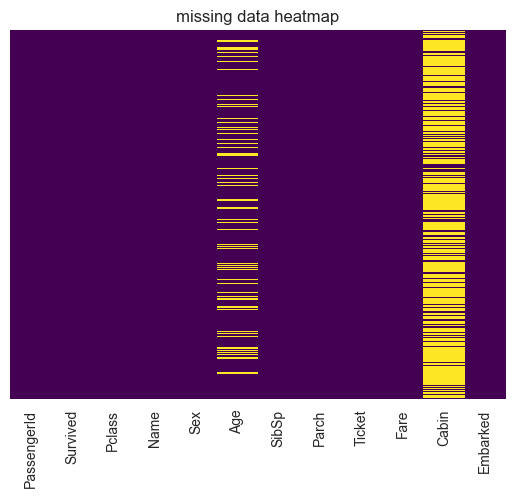

In [54]:
train = pd.read_csv('train.csv')
print(f"size of a database: {train.shape}")
print("missing values in each column:")
print(train.isnull().sum())
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('missing data heatmap')
plt.show()

In [55]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Embarked', 'Cabin', 'Fare', 'SibSp'], axis=1, inplace=True)
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

print(train.head())
print("\nmissing values after cleaning:")
print(train.isnull().sum())

   Survived  Pclass  Sex   Age  Parch
0         0       3    0  22.0      0
1         1       1    1  38.0      0
2         1       3    1  26.0      0
3         1       1    1  35.0      0
4         0       3    0  35.0      0

missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
Parch       0
dtype: int64


In [56]:
X = train.drop('Survived', axis=1)
y = train['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("sizes of the sets:")
print(f"training set (X_train): {X_train.shape}")
print(f"testing set (X_test): {X_test.shape}")
print(f"training labels (y_train): {y_train.shape}")
print(f"testing labels (y_test): {y_test.shape}")

sizes of the sets:
training set (X_train): (712, 4)
testing set (X_test): (179, 4)
training labels (y_train): (712,)
testing labels (y_test): (179,)


In [81]:
clf = DecisionTreeClassifier(random_state=42, max_depth=20)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
depth = clf.get_depth()
num_nodes = clf.tree_.node_count

print(f"tree depth: {depth}")
print(f"total number of nodes: {num_nodes}")

print("first 10 prediction:", y_pred[:15])
print("first 10 actual val:", y_test.values[:15])

tree depth: 17
total number of nodes: 287
first 10 prediction: [0 0 0 1 0 1 1 0 1 1 0 0 0 0 0]
first 10 actual val: [1 0 0 1 1 1 1 0 1 1 0 0 0 0 0]


In [82]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"accuracy:  {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\ndetailed classification report:")
print(classification_report(y_test, y_pred))

accuracy:  0.7933
precision: 0.7681
recall:    0.7162
F1-score:  0.7413

detailed classification report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



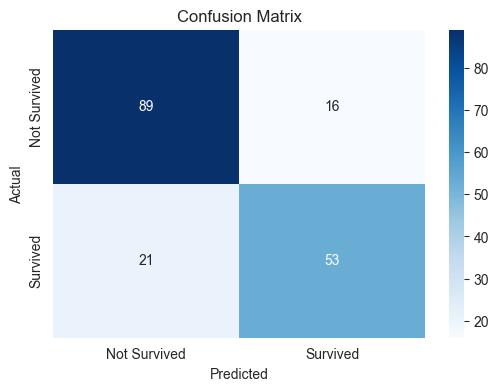

In [83]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

feature importances:
  feature  importance
1     Sex    0.410412
2     Age    0.347579
0  Pclass    0.199225
3   Parch    0.042784


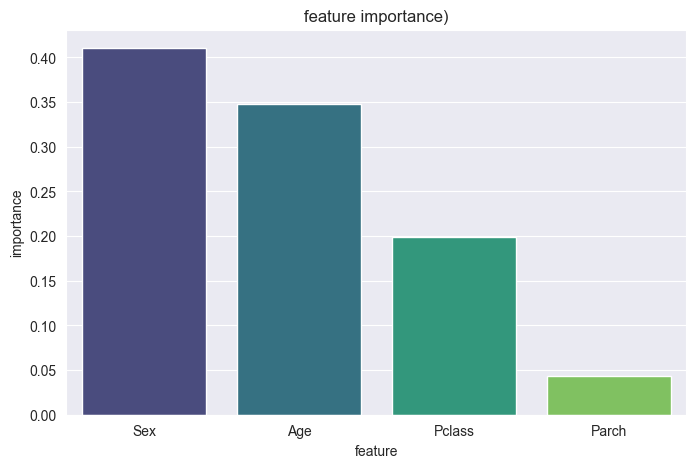

In [84]:
importances = pd.DataFrame({ 'feature': X.columns,
                             'importance': clf.feature_importances_}).sort_values(by='importance', ascending=False)
print("feature importances:")
print(importances)
plt.figure(figsize=(8, 5))
sns.barplot(x='feature', y='importance', data=importances, palette='viridis', legend=False, hue='feature')
plt.title('feature importance)')
plt.show()

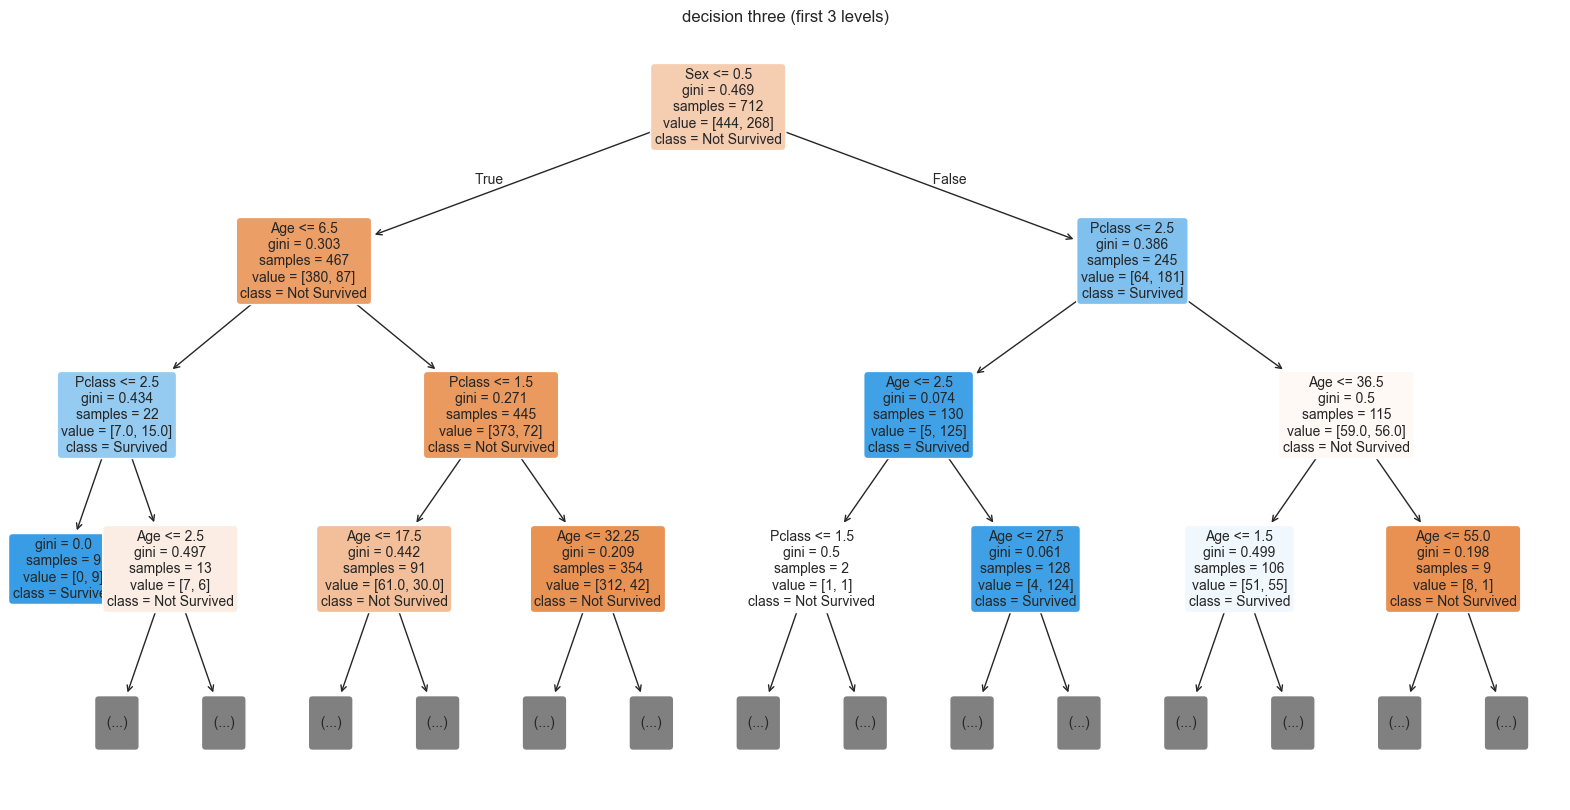

total levels: 17


In [85]:
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("decision three (first 3 levels)")
plt.show()